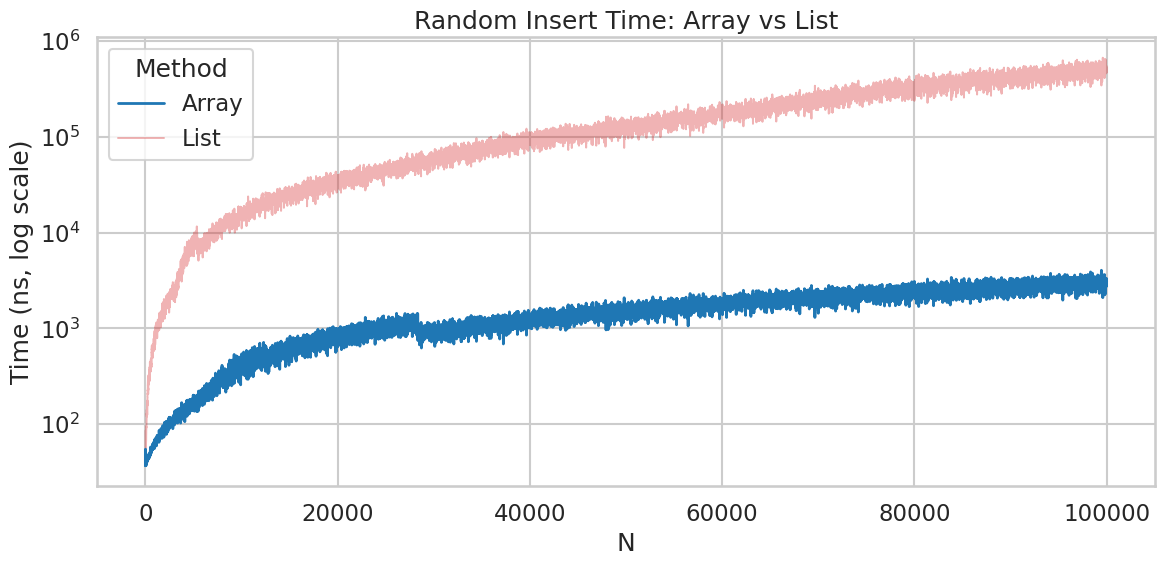

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

array_file = "array.csv"
list_file = "list.csv"

# ===== 新增参数 =====
L = None          # 左边界（包含），例如 1000；None 表示不限制
R = None         # 右边界（包含），例如 50000；None 表示不限制
USE_LOG_Y = True  # 是否开启 y 轴对数
# ====================

def load_one(path: str, method: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if method == "Array" and "array_ns_avg" in df.columns:
        time_col = "array_ns_avg"
    elif method == "List" and "list_ns_avg" in df.columns:
        time_col = "list_ns_avg"
    else:
        raise ValueError(f"{path} 中找不到 {method} 对应时间列")

    out = df[["step", time_col]].copy()
    out.columns = ["N", "time_ns"]
    out["Method"] = method
    return out

plot_df = pd.concat(
    [load_one(array_file, "Array"), load_one(list_file, "List")],
    ignore_index=True
).sort_values(["Method", "N"])

# 区间过滤
if L is not None:
    plot_df = plot_df[plot_df["N"] >= L]
if R is not None:
    plot_df = plot_df[plot_df["N"] <= R]

if plot_df.empty:
    raise ValueError("过滤后没有数据，请检查 L/R 参数")

# 可选平滑（保持你之前的可视化习惯）
plot_df["time_plot"] = (
    plot_df.groupby("Method")["time_ns"]
    .transform(lambda s: s.rolling(20, min_periods=1).median())
)

sns.set_theme(style="whitegrid", context="talk")
palette = {"Array": "#1f77b4", "List": "#d62728"}

plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=plot_df[plot_df["Method"] == "List"],
    x="N", y="time_plot",
    color=palette["List"],
    linewidth=1.4, alpha=0.35
)

sns.lineplot(
    data=plot_df[plot_df["Method"] == "Array"],
    x="N", y="time_plot",
    color=palette["Array"],
    linewidth=2.0, alpha=1.0,
    ax=ax
)

if USE_LOG_Y:
    ax.set_yscale("log")
    ylabel = "Time (ns, log scale)"
else:
    ylabel = "Time (ns)"

ax.set_xlabel("N")
ax.set_ylabel(ylabel)
ax.set_title("Random Insert Time: Array vs List")

custom_handles = [
    Line2D([0], [0], color=palette["Array"], lw=2.0, alpha=1.0, label="Array"),
    Line2D([0], [0], color=palette["List"],  lw=1.4, alpha=0.35, label="List"),
]
ax.legend(handles=custom_handles, title="Method")

plt.tight_layout()
plt.show()


/tmp/ipykernel_901143/3200982812.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = points.pivot_table(index=p_cut, columns=n_cut, values="time_ns", aggfunc=agg)


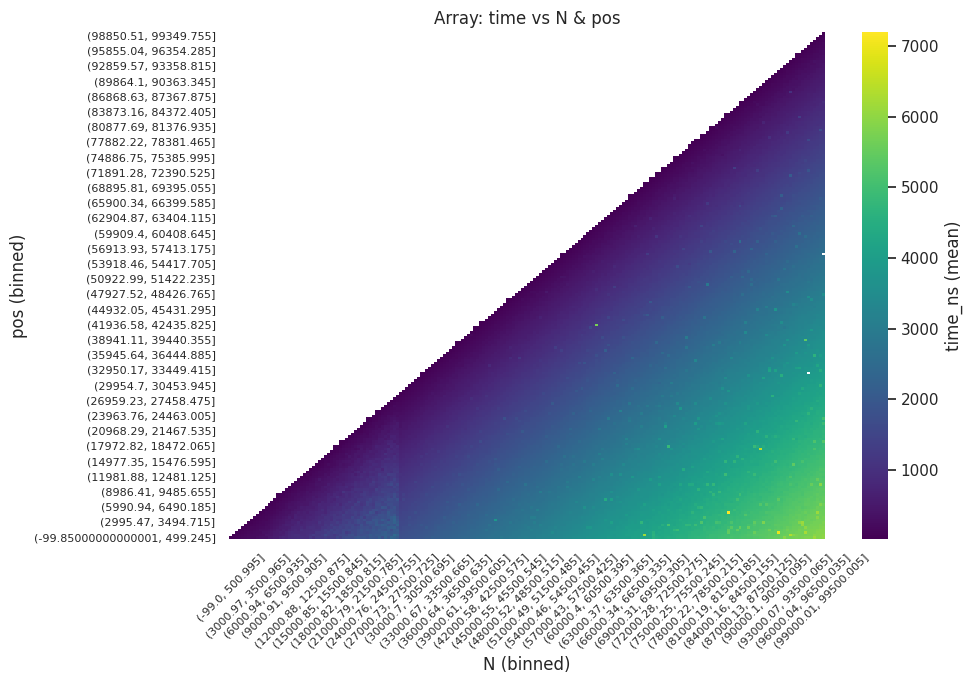

/tmp/ipykernel_901143/3200982812.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = points.pivot_table(index=p_cut, columns=n_cut, values="time_ns", aggfunc=agg)


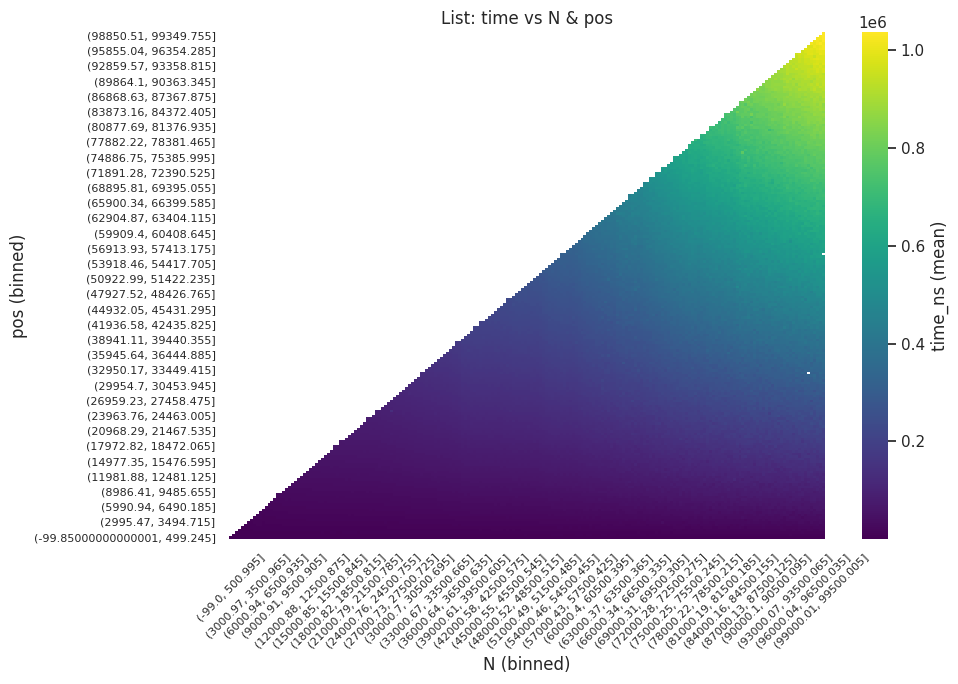

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ====== 你可调的参数 ======
ARRAY_CSV = "array.csv"
LIST_CSV = "list.csv"

N_BINS = 200          # X轴 N 分箱
POS_BINS = 200        # Y轴 pos 分箱
AGG = "mean"         # mean / median
CMAP = "viridis"
# =========================

def extract_points(df: pd.DataFrame, method: str) -> pd.DataFrame:
    # 兼容新格式(pos_seed_x + *_ns_seed_x)和旧格式(position + *_ns)
    time_prefix = "array_ns_seed_" if method == "Array" else "list_ns_seed_"
    seed_pos_cols = sorted([c for c in df.columns if c.startswith("pos_seed_")])

    parts = []
    if seed_pos_cols:
        for pos_col in seed_pos_cols:
            seed = pos_col.replace("pos_seed_", "")
            time_col = f"{time_prefix}{seed}"
            if time_col in df.columns:
                parts.append(pd.DataFrame({
                    "N": df["step"].astype(int),
                    "pos": df[pos_col].astype(int),
                    "time_ns": df[time_col].astype(float),
                }))

    if not parts:
        legacy_time_col = "array_ns" if method == "Array" else "list_ns"
        if "position" in df.columns and legacy_time_col in df.columns:
            parts.append(pd.DataFrame({
                "N": df["step"].astype(int),
                "pos": df["position"].astype(int),
                "time_ns": df[legacy_time_col].astype(float),
            }))

    if not parts:
        raise ValueError(f"找不到 {method} 对应的 pos/time 列")

    return pd.concat(parts, ignore_index=True)

def build_mat(points: pd.DataFrame, n_bins, pos_bins, agg="mean") -> pd.DataFrame:
    n_cut = pd.cut(points["N"], bins=n_bins, include_lowest=True, duplicates="drop")
    p_cut = pd.cut(points["pos"], bins=pos_bins, include_lowest=True, duplicates="drop")
    mat = points.pivot_table(index=p_cut, columns=n_cut, values="time_ns", aggfunc=agg)
    return mat.sort_index(ascending=True)

sns.set_theme(style="white")

# ===== Array 图 =====
array_df = pd.read_csv(ARRAY_CSV)
array_points = extract_points(array_df, "Array")
array_mat = build_mat(array_points, N_BINS, POS_BINS, AGG)

plt.figure(figsize=(10, 7))
ax = sns.heatmap(array_mat, cmap=CMAP, cbar_kws={"label": f"time_ns ({AGG})"})
ax.set_title("Array: time vs N & pos")
ax.set_xlabel("N (binned)")
ax.set_ylabel("pos (binned)")
ax.invert_yaxis()
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

# ===== List 图 =====
list_df = pd.read_csv(LIST_CSV)
list_points = extract_points(list_df, "List")
list_mat = build_mat(list_points, N_BINS, POS_BINS, AGG)

plt.figure(figsize=(10, 7))
ax = sns.heatmap(list_mat, cmap=CMAP, cbar_kws={"label": f"time_ns ({AGG})"})
ax.set_title("List: time vs N & pos")
ax.set_xlabel("N (binned)")
ax.set_ylabel("pos (binned)")
ax.invert_yaxis()
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


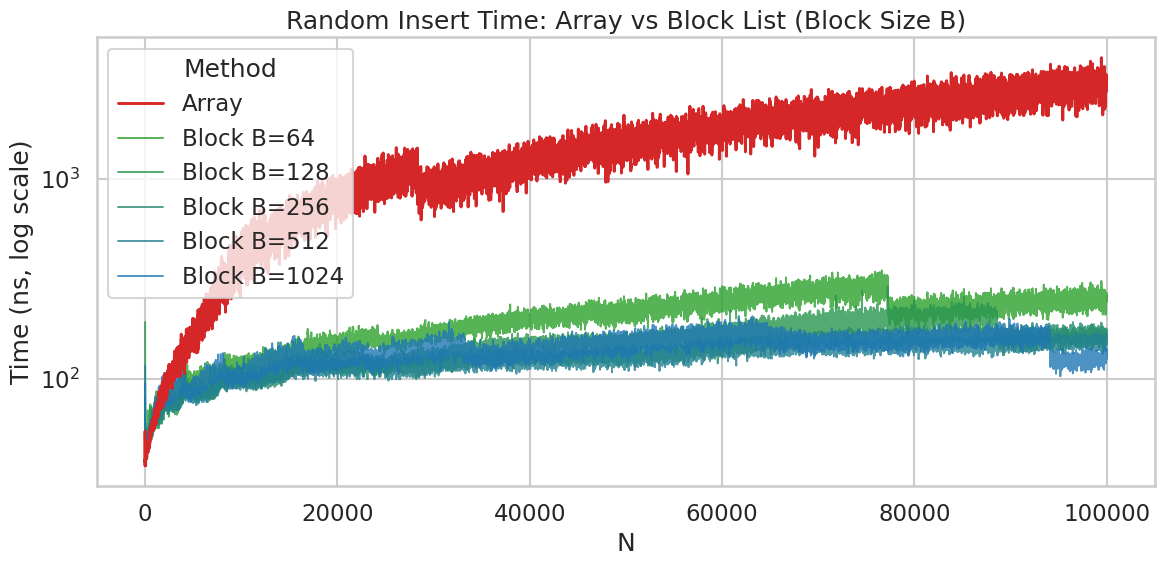

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ====== 你给定的文件 ======
array_file = "array.csv"
block_files = {
    "Block B=64": "block64.csv",
    "Block B=128": "block128.csv",
    "Block B=256": "block256.csv",
    #"Block B=316": "block316.csv",
    "Block B=512": "block512.csv",
    "Block B=1024": "block1024.csv",
}
L = None          # 左边界(包含)，如 1000；None 不限制
R = None         # 右边界(包含)，如 50000；None 不限制
USE_LOG_Y = True  # 是否开启 log y
ROLLING = 20     # 平滑窗口
# =========================

def load_array(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "array_ns_avg" in df.columns:
        t = df["array_ns_avg"]
    elif "array_ns" in df.columns:
        t = df["array_ns"]
    else:
        raise ValueError(f"{path} 缺少 array 时间列")
    out = pd.DataFrame({"N": df["step"].astype(int), "time_ns": t.astype(float)})
    out["Method"] = "Array"
    return out

def load_block(path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "block_ns_avg" in df.columns:
        t = df["block_ns_avg"]
    elif "block_ns" in df.columns:
        t = df["block_ns"]
    else:
        seed_cols = [c for c in df.columns if c.startswith("block_ns_seed_")]
        if not seed_cols:
            raise ValueError(f"{path} 缺少 block 时间列")
        t = df[seed_cols].mean(axis=1)
    out = pd.DataFrame({"N": df["step"].astype(int), "time_ns": t.astype(float)})
    out["Method"] = label
    return out

frames = [load_array(array_file)]
for label, path in block_files.items():
    frames.append(load_block(path, label))

plot_df = pd.concat(frames, ignore_index=True).sort_values(["Method", "N"])

if L is not None:
    plot_df = plot_df[plot_df["N"] >= L]
if R is not None:
    plot_df = plot_df[plot_df["N"] <= R]
if plot_df.empty:
    raise ValueError("过滤后无数据，请检查 L/R")

plot_df["time_plot"] = (
    plot_df.groupby("Method")["time_ns"]
    .transform(lambda s: s.rolling(ROLLING, min_periods=1).median())
)

sns.set_theme(style="whitegrid", context="talk")
import seaborn as sns

# Array 固定红色；Block 按 L 从小到大做 绿->蓝 渐变
palette = {"Array": "#d62728"}

block_labels = list(block_files.keys())  # 例如 "Block L=64"
block_labels_sorted = sorted(block_labels, key=lambda s: int(s.split("=")[1]))
gb_colors = sns.blend_palette(["#2ca02c", "#1f77b4"], n_colors=len(block_labels_sorted))

for lbl, c in zip(block_labels_sorted, gb_colors):
    palette[lbl] = c


plt.figure(figsize=(12, 6))
ax = plt.gca()

# 先画 block（半透明）
for label in block_files.keys():
    d = plot_df[plot_df["Method"] == label]
    sns.lineplot(
        data=d, x="N", y="time_plot",
        color=palette[label],
        linewidth=1.4, alpha=0.8,
        ax=ax, legend=False
    )

# 再画 Array（突出）
d_arr = plot_df[plot_df["Method"] == "Array"]
sns.lineplot(
    data=d_arr, x="N", y="time_plot",
    color=palette["Array"],
    linewidth=2.1, alpha=1.0,
    ax=ax, legend=False
)

if USE_LOG_Y:
    ax.set_yscale("log")
    ylabel = "Time (ns, log scale)"
else:
    ylabel = "Time (ns)"

ax.set_xlabel("N")
ax.set_ylabel(ylabel)
ax.set_title("Random Insert Time: Array vs Block List (Block Size B)")

handles = [Line2D([0], [0], color=palette["Array"], lw=2.1, alpha=1.0, label="Array")]
for label in block_files.keys():
    handles.append(Line2D([0], [0], color=palette[label], lw=1.4, alpha=0.8, label=label))
ax.legend(handles=handles, title="Method")

plt.tight_layout()
plt.show()


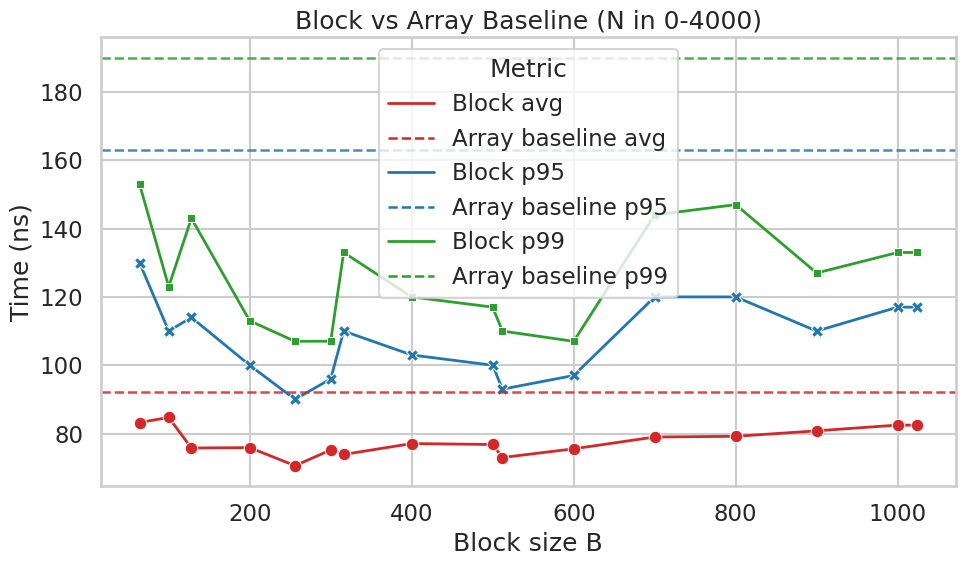

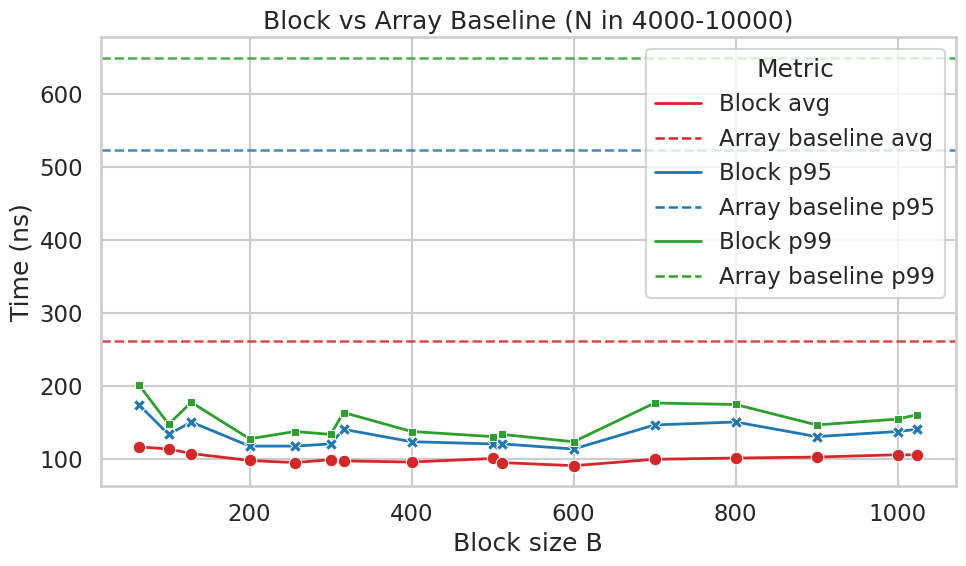

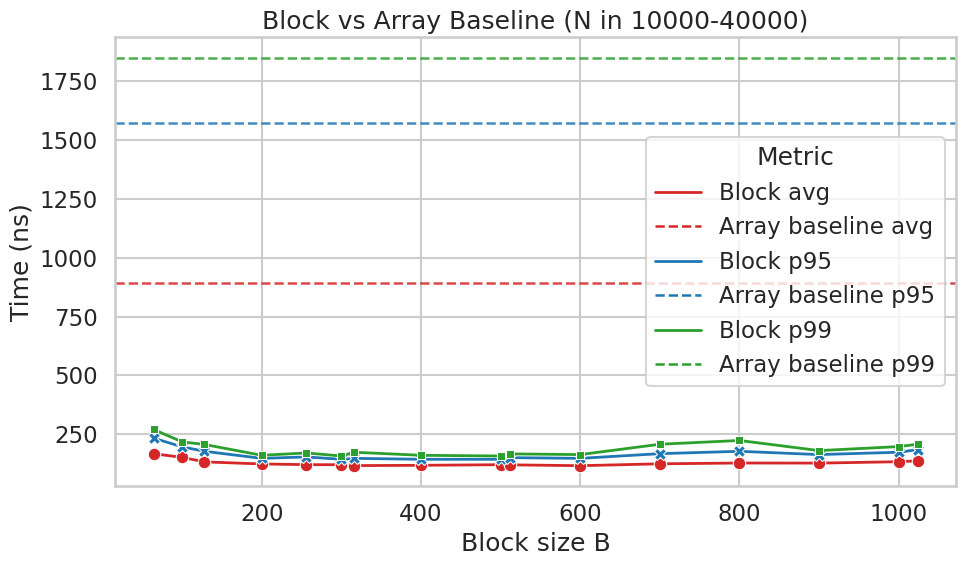

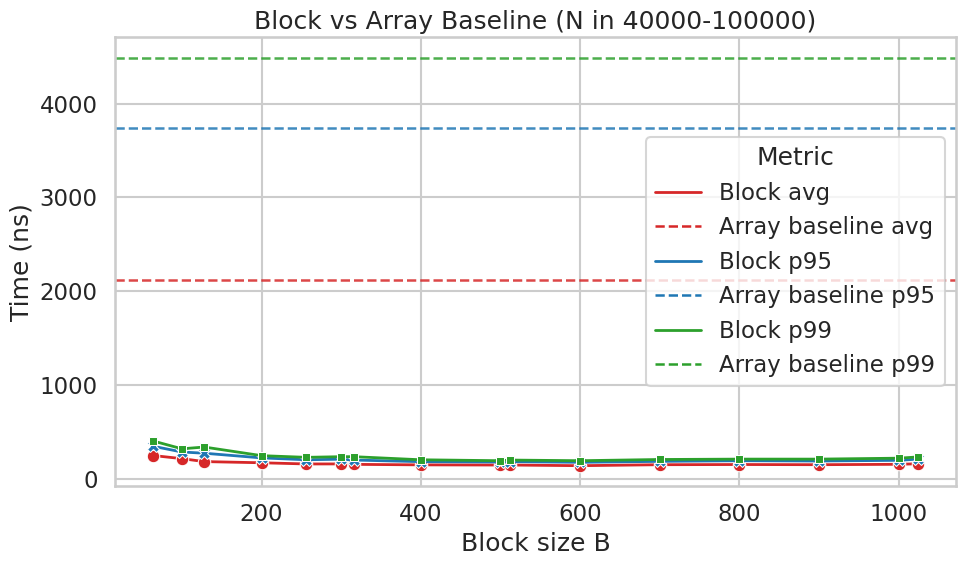

In [11]:
import re
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 自动定位 data 目录
DATA_DIR = Path("data") if Path("data").exists() else Path(".")

# N 区间（首段 [0,4000]，其余 (L,R]）
INTERVALS = [
    ("0-4000", 0, 4000),
    ("4000-10000", 4000, 10000),
    ("10000-40000", 10000, 40000),
    ("40000-100000", 40000, 100000),
]

ARRAY_FILE = DATA_DIR / "array.csv"
PALETTE = {"avg": "#d62728", "p95": "#1f77b4", "p99": "#2ca02c"}

sns.set_theme(style="whitegrid", context="talk")


def parse_block_size(filename: str):
    m = re.match(r"block(\d+)\.csv$", filename)
    return int(m.group(1)) if m else None


def load_array_series(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "array_ns_avg" in df.columns:
        t = df["array_ns_avg"].astype(float)
    elif "array_ns" in df.columns:
        t = df["array_ns"].astype(float)
    else:
        seed_cols = [c for c in df.columns if c.startswith("array_ns_seed_")]
        if not seed_cols:
            raise ValueError(f"{path} 缺少 array 时间列")
        t = df[seed_cols].mean(axis=1).astype(float)
    return pd.DataFrame({"N": df["step"].astype(int), "time_ns": t})


def load_block_series(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "block_ns_avg" in df.columns:
        t = df["block_ns_avg"].astype(float)
    elif "block_ns" in df.columns:
        t = df["block_ns"].astype(float)
    else:
        seed_cols = [c for c in df.columns if c.startswith("block_ns_seed_")]
        if not seed_cols:
            raise ValueError(f"{path} 缺少 block 时间列")
        t = df[seed_cols].mean(axis=1).astype(float)
    return pd.DataFrame({"N": df["step"].astype(int), "time_ns": t})


def slice_interval(df: pd.DataFrame, low: int, high: int) -> pd.DataFrame:
    if low == 0:
        return df[(df["N"] >= low) & (df["N"] <= high)]
    return df[(df["N"] > low) & (df["N"] <= high)]


# 读取 block 文件
block_files = []
for p in DATA_DIR.glob("block*.csv"):
    L = parse_block_size(p.name)
    if L is not None:
        block_files.append((L, p))
block_files.sort(key=lambda x: x[0])

if not block_files:
    raise ValueError(f"在 {DATA_DIR.resolve()} 下未找到 block*.csv")
if not ARRAY_FILE.exists():
    raise ValueError(f"未找到 {ARRAY_FILE}")

array_series = load_array_series(ARRAY_FILE)
block_series_by_L = {L: load_block_series(p) for L, p in block_files}
block_sizes = [L for L, _ in block_files]

for label, low, high in INTERVALS:
    # block 统计
    rows = []
    for L in block_sizes:
        part = slice_interval(block_series_by_L[L], low, high)
        if part.empty:
            continue
        rows.append({"block_size": L, "metric": "avg", "time_ns": part["time_ns"].mean()})
        rows.append({"block_size": L, "metric": "p95", "time_ns": part["time_ns"].quantile(0.95)})
        rows.append({"block_size": L, "metric": "p99", "time_ns": part["time_ns"].quantile(0.99)})
    block_plot_df = pd.DataFrame(rows)
    if block_plot_df.empty:
        print(f"[{label}] block 无数据，跳过")
        continue

    # array baseline（每个区间一个 avg/p95/p99）
    arr_part = slice_interval(array_series, low, high)
    if arr_part.empty:
        print(f"[{label}] array 无数据，跳过")
        continue
    array_baseline = {
        "avg": arr_part["time_ns"].mean(),
        "p95": arr_part["time_ns"].quantile(0.95),
        "p99": arr_part["time_ns"].quantile(0.99),
    }

    plt.figure(figsize=(10, 6))
    ax = sns.lineplot(
        data=block_plot_df,
        x="block_size",
        y="time_ns",
        hue="metric",
        style="metric",
        markers=True,
        dashes=False,
        linewidth=2.0,
        palette=PALETTE,
        legend=False,  # 自定义 legend
    )

    # 加 array baseline（同色虚线）
    for m, y in array_baseline.items():
        ax.axhline(y=y, color=PALETTE[m], linestyle="--", linewidth=1.8, alpha=0.85)

    ax.set_title(f"Block vs Array Baseline (N in {label})")
    ax.set_xlabel("Block size B")
    ax.set_ylabel("Time (ns)")

    # 自定义 legend：实线=Block，虚线=Array baseline
    handles = []
    for m in ["avg", "p95", "p99"]:
        handles.append(Line2D([0], [0], color=PALETTE[m], lw=2.0, linestyle="-", label=f"Block {m}"))
        handles.append(Line2D([0], [0], color=PALETTE[m], lw=1.8, linestyle="--", label=f"Array baseline {m}"))
    ax.legend(handles=handles, title="Metric")

    plt.tight_layout()
    plt.show()


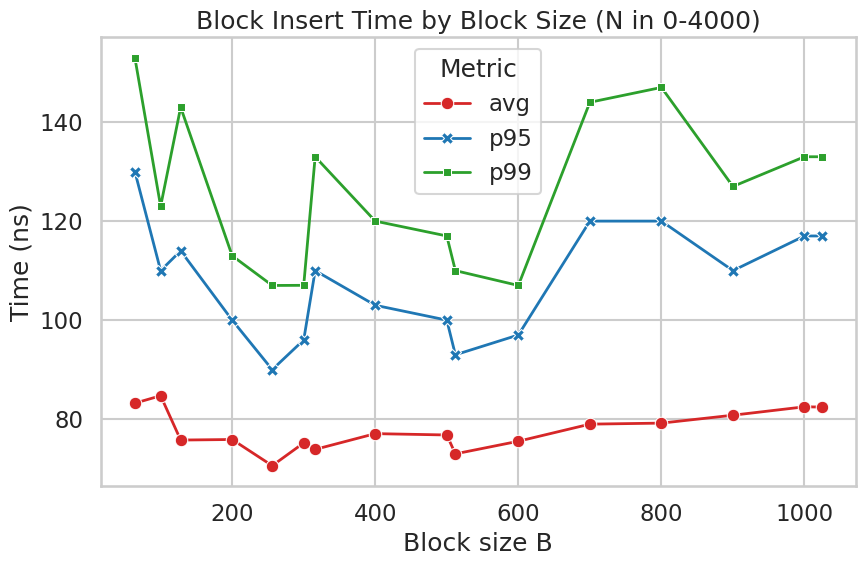

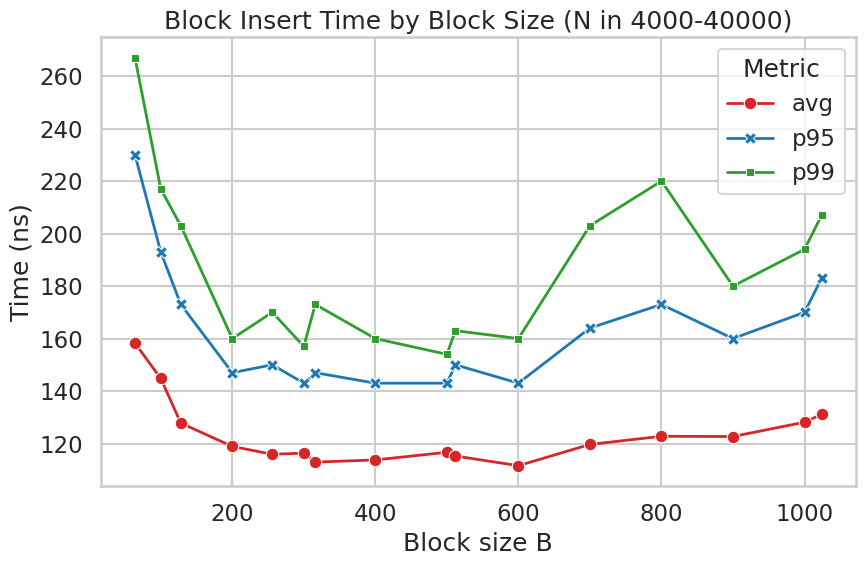

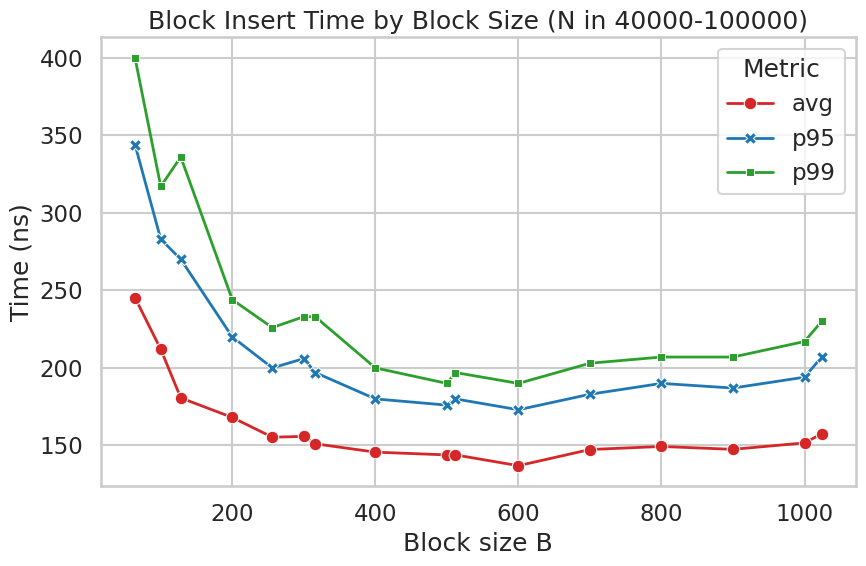

In [14]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 自动定位 data 目录（如果当前就在 data/ 下，会退回到当前目录）
DATA_DIR = Path("data") if Path("data").exists() else Path(".")

# N 区间（首段含左边界，其余用 (L, R] 避免重复）
INTERVALS = [
    ("0-4000", 0, 4000),
    ("4000-40000", 4000, 40000),
    ("40000-100000", 40000, 100000),
]

sns.set_theme(style="whitegrid", context="talk")

def parse_block_size(filename: str):
    m = re.match(r"block(\d+)\.csv$", filename)
    return int(m.group(1)) if m else None

def load_block_series(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "step" not in df.columns:
        raise ValueError(f"{path} 缺少 step 列")

    if "block_ns_avg" in df.columns:
        t = df["block_ns_avg"].astype(float)
    elif "block_ns" in df.columns:
        t = df["block_ns"].astype(float)
    else:
        seed_cols = [c for c in df.columns if c.startswith("block_ns_seed_")]
        if not seed_cols:
            raise ValueError(f"{path} 缺少 block 时间列")
        t = df[seed_cols].mean(axis=1).astype(float)

    return pd.DataFrame({"N": df["step"].astype(int), "time_ns": t})

# 收集 block*.csv（只匹配 block64.csv / block128.csv 这类）
block_files = []
for p in DATA_DIR.glob("block*.csv"):
    L = parse_block_size(p.name)
    if L is not None:
        block_files.append((L, p))
block_files.sort(key=lambda x: x[0])

if not block_files:
    raise ValueError(f"在 {DATA_DIR.resolve()} 下未找到 block*.csv（如 block64.csv）")

# 预加载
series_by_L = {L: load_block_series(p) for L, p in block_files}

palette = {"avg": "#d62728", "p95": "#1f77b4", "p99": "#2ca02c"}

for label, low, high in INTERVALS:
    rows = []
    for L, _ in block_files:
        s = series_by_L[L]
        if low == 0:
            part = s[(s["N"] >= low) & (s["N"] <= high)]
        else:
            part = s[(s["N"] > low) & (s["N"] <= high)]

        if part.empty:
            continue

        rows.append({"block_size": L, "metric": "avg", "time_ns": part["time_ns"].mean()})
        rows.append({"block_size": L, "metric": "p95", "time_ns": part["time_ns"].quantile(0.95)})
        rows.append({"block_size": L, "metric": "p99", "time_ns": part["time_ns"].quantile(0.99)})

    plot_df = pd.DataFrame(rows)
    if plot_df.empty:
        print(f"[{label}] 无数据，跳过")
        continue

    plt.figure(figsize=(9, 6))
    ax = sns.lineplot(
        data=plot_df,
        x="block_size",
        y="time_ns",
        hue="metric",
        style="metric",
        markers=True,
        dashes=False,
        linewidth=2.0,
        palette=palette,
    )
    ax.set_title(f"Block Insert Time by Block Size (N in {label})")
    ax.set_xlabel("Block size B")
    ax.set_ylabel("Time (ns)")
    ax.legend(title="Metric")
    plt.tight_layout()
    plt.show()
